# Unit 2 code companion: Probability and Random Variables

The simulations behind the slides: why real randomness clumps, what independence buys you and what it costs when it fails, Bayes by counting people, and why the average is the wrong number to plan on.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. Real randomness clumps

The fake-a-coin demo, settled by simulation. We measure the longest run of the same side in a sequence of honest flips.

50 honest flips: mean longest run = 5.96, median = 6, 90th pct = 8
P(longest run <= 3) = 0.020   <-- where most invented sequences live


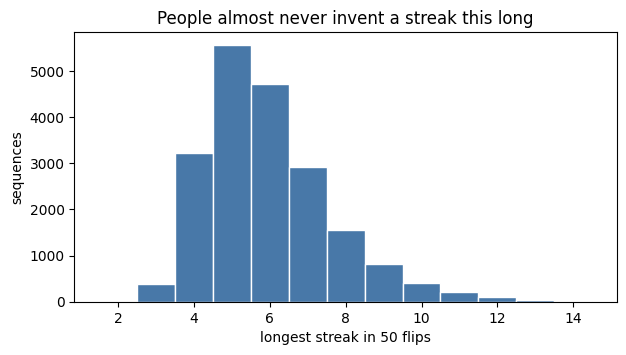

In [2]:
def longest_run(seq):
    best = run = 1
    for i in range(1, len(seq)):
        run = run + 1 if seq[i] == seq[i-1] else 1
        best = max(best, run)
    return best

runs = np.array([longest_run(rng.integers(0, 2, 50)) for _ in range(20_000)])
print(f"50 honest flips: mean longest run = {runs.mean():.2f}, "
      f"median = {np.median(runs):.0f}, 90th pct = {np.percentile(runs, 90):.0f}")
print(f"P(longest run <= 3) = {(runs <= 3).mean():.3f}   <-- where most invented sequences live")

plt.hist(runs, bins=np.arange(1.5, 15.5), color="#4878a8", edgecolor="white")
plt.xlabel("longest streak in 50 flips"); plt.ylabel("sequences")
plt.title("People almost never invent a streak this long"); plt.show()

## 1b. The detector, so you can try to fool it

Same 120 reference sequences the slides use. Type your invented sequence into `check()` and it will tell you whether a person wrote it.

In [3]:
REF_SEED, N_FLIPS, N_REF = 20260817, 50, 120
ref_rng = np.random.default_rng(REF_SEED)
reference = ["".join("HT"[b] for b in ref_rng.integers(0, 2, N_FLIPS)) for _ in range(N_REF)]

def switch_rate(seq):
    return sum(seq[i] != seq[i-1] for i in range(1, len(seq))) / (len(seq) - 1)

ref_runs = np.array([longest_run(s) for s in reference])
ref_switch = np.array([switch_rate(s) for s in reference])
print(f"reference: {N_REF} real sequences of {N_FLIPS} flips")
print(f"  longest run  mean {ref_runs.mean():.2f}, range {ref_runs.min()} to {ref_runs.max()}")
print(f"  P(longest run <= 4) = {(ref_runs <= 4).mean():.2f}")
print(f"  switch rate  mean {ref_switch.mean():.2f}")

reference: 120 real sequences of 50 flips
  longest run  mean 5.83, range 3 to 12
  P(longest run <= 4) = 0.22
  switch rate  mean 0.50


In [4]:
def check(raw):
    seq = "".join(c for c in raw.upper() if c in "HT01").replace("0", "T").replace("1", "H")
    run, sw = longest_run(seq), switch_rate(seq)
    flags = []
    if run <= 4:
        flags.append(f"longest run of {run}: only {100*(ref_runs <= run).mean():.0f}% of real "
                     f"sequences are that short")
    if sw >= 0.60:
        flags.append(f"alternates {100*sw:.0f}% of the time, real coins sit near 50%")
    print(f"{len(seq)} flips, {seq.count('H')} heads, longest run {run}, "
          f"alternates {100*sw:.0f}%")
    print("VERDICT: a person wrote this" if flags else "VERDICT: could be a real coin")
    for f in flags:
        print("   -", f)

check("HTHTTHTHHTHTTHTHHTHTTHTHHTHTTHTHHTHTTHTHHTHTTHTHHT")   # a typical human attempt
print()
check(reference[0])                                            # a real one

50 flips, 25 heads, longest run 2, alternates 76%
VERDICT: a person wrote this
   - longest run of 2: only 0% of real sequences are that short
   - alternates 76% of the time, real coins sit near 50%

50 flips, 24 heads, longest run 5, alternates 49%
VERDICT: could be a real coin


Try your own. The two tells are independent of each other, so a sequence has to get *both* right to pass, which is why almost nobody does it on the first attempt.

## 2. Rare events stop being rare when you get many chances



In [5]:
p_day = 0.01
for days in [1, 7, 30, 90, 365]:
    print(f"{days:4d} days: P(at least one outage) = {1 - (1-p_day)**days:.3f}")

   1 days: P(at least one outage) = 0.010
   7 days: P(at least one outage) = 0.068
  30 days: P(at least one outage) = 0.260
  90 days: P(at least one outage) = 0.595
 365 days: P(at least one outage) = 0.974


## 3. What false independence costs you

Three data centers, each with a 1% monthly failure rate. The only thing that changes between the two worlds is whether they share a common shock.

In [6]:
n_sims = 500_000

# World 1: truly independent failures.
indep = rng.random((n_sims, 3)) < 0.01

# World 2: same 1% marginal rate, but part of the risk is a shared regional shock.
shock = rng.random(n_sims) < 0.004                      # hits everything at once
local = rng.random((n_sims, 3)) < 0.006                 # independent local causes
corr = local | shock[:, None]

for name, arr in [("independent", indep), ("shared shock", corr)]:
    marg = arr.mean()
    all_three = arr.all(axis=1).mean()
    print(f"{name:>14}: per-site rate = {marg:.4f}   P(all three down) = {all_three:.6f}")

print(f"\nThe naive answer 0.01^3 = {0.01**3:.6f}")
print("Same per-site risk. The joint risk differs by orders of magnitude.")

   independent: per-site rate = 0.0100   P(all three down) = 0.000004
  shared shock: per-site rate = 0.0099   P(all three down) = 0.003912

The naive answer 0.01^3 = 0.000001
Same per-site risk. The joint risk differs by orders of magnitude.


This is the 2008 mortgage problem in eight lines. Every marginal probability is identical. Only the dependence changed. Any model that priced the joint risk from the marginals alone would have called the second world impossible.

## 4. Bayes by counting people

Never manipulate the formula under pressure. Build the table.

In [7]:
def screening_table(prevalence, sensitivity, specificity, population=10_000):
    sick = population * prevalence
    well = population - sick
    tp, fn = sick * sensitivity, sick * (1 - sensitivity)
    fp, tn = well * (1 - specificity), well * specificity
    ppv = tp / (tp + fp)
    print(f"population {population:,}, prevalence {prevalence:.1%}")
    print(f"  sick     : {sick:8.0f}  ->  {tp:7.0f} test positive, {fn:7.0f} missed")
    print(f"  healthy  : {well:8.0f}  ->  {fp:7.0f} FALSE positives")
    print(f"  P(sick | positive) = {tp:.0f}/({tp:.0f}+{fp:.0f}) = {ppv:.1%}\n")
    return ppv

screening_table(0.01, 0.99, 0.95)
screening_table(0.30, 0.99, 0.95)

population 10,000, prevalence 1.0%
  sick     :      100  ->       99 test positive,       1 missed
  healthy  :     9900  ->      495 FALSE positives
  P(sick | positive) = 99/(99+495) = 16.7%

population 10,000, prevalence 30.0%
  sick     :     3000  ->     2970 test positive,      30 missed
  healthy  :     7000  ->      350 FALSE positives
  P(sick | positive) = 2970/(2970+350) = 89.5%



0.894578313253012

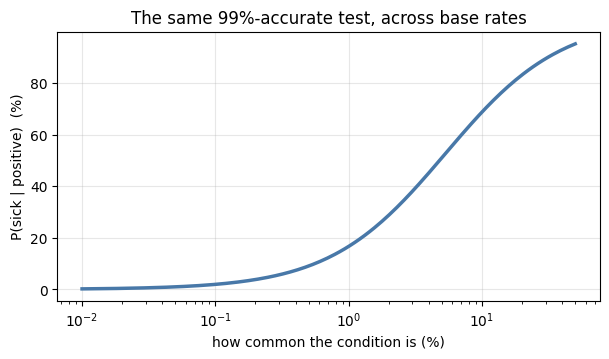

In [8]:
prev = np.logspace(-4, -0.3, 200)
ppv = 0.99*prev / (0.99*prev + 0.05*(1-prev))
plt.semilogx(prev*100, ppv*100, color="#4878a8", lw=2.5)
plt.xlabel("how common the condition is (%)"); plt.ylabel("P(sick | positive)  (%)")
plt.title("The same 99%-accurate test, across base rates"); plt.grid(alpha=.3); plt.show()

The test never changed. Only the population did. This single curve explains why a fraud model that looks brilliant on a balanced test set floods the review queue in production.

## 5. Linearity, and why variance is different

Expectations always add. Variances only add when the pieces are independent.

In [9]:
# Expected daily revenue for a call center, by simulation and by linearity.
calls, p_buy, basket = 400, 0.06, 85.0
sim = rng.binomial(calls, p_buy, size=200_000) * basket
print(f"simulated mean revenue : ${sim.mean():,.2f}")
print(f"linearity says         : ${calls * p_buy * basket:,.2f}")
print(f"simulated SD           : ${sim.std():,.2f}")
print(f"formula sqrt(n p (1-p)) * basket = ${np.sqrt(calls*p_buy*(1-p_buy))*basket:,.2f}")

simulated mean revenue : $2,040.29
linearity says         : $2,040.00
simulated SD           : $403.61
formula sqrt(n p (1-p)) * basket = $403.73


In [10]:
# Averaging n cases: independent vs correlated.
def sd_of_average(n, rho):
    base = rng.normal(size=(20_000, n))
    common = rng.normal(size=(20_000, 1))
    x = np.sqrt(1-rho)*base + np.sqrt(rho)*common     # each has SD 1, pairwise corr rho
    return x.mean(axis=1).std()

print(f"{'n':>6} {'independent':>13} {'rho=0.2':>10}")
for n in [1, 10, 100, 1000]:
    print(f"{n:>6} {sd_of_average(n, 0.0):>13.3f} {sd_of_average(n, 0.2):>10.3f}")
print(f"\nfloor for rho=0.2 is sqrt(0.2) = {np.sqrt(0.2):.3f}: more data never gets below it")

     n   independent    rho=0.2
     1         1.005      1.000
    10         0.319      0.534
   100         0.100      0.457


  1000         0.032      0.448

floor for rho=0.2 is sqrt(0.2) = 0.447: more data never gets below it


## 6. The flaw of averages, with real demand

Daily bike rentals. Suppose each bike costs $3 for the day and each rental earns $9.

mean demand                          : 699 bikes
profit IF demand equalled the mean   : $4,194
ACTUAL average profit at that fleet  : $2,520
profit-maximizing fleet              : 970 bikes  ($2,726)


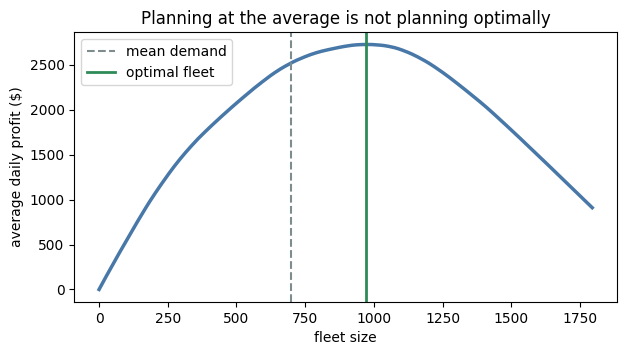

In [11]:
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv")
demand = bikes["Count"].values

def profit(fleet, d):
    return 9*np.minimum(d, fleet) - 3*fleet

mean_demand = int(round(demand.mean()))
print(f"mean demand                          : {demand.mean():.0f} bikes")
print(f"profit IF demand equalled the mean   : ${profit(mean_demand, mean_demand):,.0f}")
print(f"ACTUAL average profit at that fleet  : ${profit(mean_demand, demand).mean():,.0f}")

fleets = np.arange(0, demand.max()+1, 5)
avg_profit = np.array([profit(f, demand).mean() for f in fleets])
best = fleets[avg_profit.argmax()]
print(f"profit-maximizing fleet              : {best} bikes  (${avg_profit.max():,.0f})")

plt.plot(fleets, avg_profit, color="#4878a8", lw=2.5)
plt.axvline(mean_demand, color="#7f8c8d", ls="--", label="mean demand")
plt.axvline(best, color="#2e8b57", lw=2, label="optimal fleet")
plt.xlabel("fleet size"); plt.ylabel("average daily profit ($)")
plt.legend(); plt.title("Planning at the average is not planning optimally"); plt.show()

Two lessons in one plot. The profit you *predict* by plugging in average demand is far above what you actually earn, and the *best* fleet is not the average demand either. It sits where the cost of an idle bike balances the cost of a missed rental.